Dataset Loaded Successfully! Shape: (178, 13)

Starting Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters Found: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

--- Final Model Performance ---
Accuracy: 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



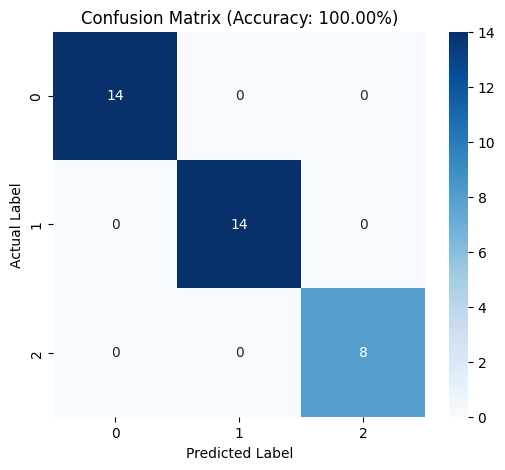

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = load_wine()
X = data.data
y = data.target

df_feat = pd.DataFrame(X, columns=data.feature_names)
print(f"Dataset Loaded Successfully! Shape: {df_feat.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\nStarting Grid Search...")

param_grid = {
'C': [0.1, 1, 10, 100],
'gamma': [1, 0.1, 0.01, 0.001],
'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)
grid.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid.best_params_}")

y_pred = grid.predict(X_test)

print("\n--- Final Model Performance ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Accuracy: {acc:.2%})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()